In [1]:
%matplotlib widget
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'
import warp as wp; wp.init()

import torch
# from compressibleSPH.gencase import *
from compressibleSPH.sample import generateInitialVariables, SamplingScheme
from compressibleSPH.sampling import  sampleParticles
# from waves.util import plotState, plotInitialState
# from simulation import runSimulation
from compressibleSPH.utils import getCurrentTimestamp
from argparse import ArgumentParser
from compressibleSPH.casefile import argparse_defaults_from_casefile, load_casefile

# from compressibleSPH.systemv3 import WaveSystemStatev3
from compressibleSPH.sample import smoothState
# from compressibleSPH.systemv3 import WaveSystemv3, f_wave_equation
from integrators.integration import *
from compressibleSPH.utils import *
from sphWarpCore import *
# from compressibleSPH.systemv3 import WaveSystemStatev3

from sphWarpCore.radiusSearch.verlet import *
from sphWarpCore.radius import AdjacencyList
from sphWarpCore.operations import *
from sphWarpCore.enumTypes import *

from sphWarpCore import *
# from waves.sampling import sampleParticles
# from compressibleSPH.systemv3 import sampleInitialWaveState
# from compressibleSPH.systemv3 import computeDt
from compressibleSPH.sampling import finalizeWaveSystemSetup
from compressibleSPH.shape_generation import populateSourceObstacleGridsStructured

from compressibleSPH.config import SimulationConfig, CompressibleSPHConfig
from compressibleSPH.caseUtils.sod import *
from compressibleSPH.util import *
from compressibleSPH.schemes import *
from sphWarpCore.diffusion.viscosity import DiffusionParameters

from diffSPH.enums import ViscositySwitch, KernelType
from torch.profiler import profile, record_function, ProfilerActivity
from tqdm.autonotebook import tqdm

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
nx = 2**16
gamma = 5/3
leftState = sodInitialState(1, 1, 0)
rightState = sodInitialState(0.1795, 0.25, 0)
samplingRatio = 1
smoothIC = True
timeLimit = 0.15

L = 2
dim = 1
n_h = 4
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32

config = SimulationConfig(
    domain = buildDomainDescription(L, dim, True, device, dtype),
    dim = dim,
    kernel = KernelFunctions.Wendland2,
    targetNeighbors = n_h_to_nH(n_h, dim),
    supportMode = SupportScheme.Gather,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta4,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = 1e-3,
    adaptiveDt = False,
    cflFactor=0.3,
)

diffusionParams = DiffusionParameters()
diffusionParams.c_s = 1
diffusionParams.C_l = 1
diffusionParams.C_q = 0
diffusionParams.Cu_l = 1
diffusionParams.Cu_q = 0
diffusionParams.K = 1.0
diffusionParams.thermalConductivity = 0.5
diffusionParams.viscosityTerm = 7
diffusionParams.thermalConducitiyTerm = 9
diffusionParams.scaleBeta = False
diffusionParams.monaghanSwitch = True
diffusionParams.correctXi = True

compressibleSPHConfig = CompressibleSPHConfig(
    gamma = gamma,
    rho0 = leftState.rho,
    diffusionParams = diffusionParams,
)
integrator = getIntegrator(config.integrationScheme)


In [3]:
from sphWarpCore.kernels.wp_kernel import sphKernel_xi
targetCFL = 0.3
# The initial state contains density and pressure
# we can get the internal energies for each state via the gas EOS
u_left = leftState.p / ((gamma - 1) * leftState.rho)
u_right = rightState.p / ((gamma - 1) * rightState.rho)
# this then gives us the speed of sound for each state, which we can use to determine the initial timestep based on the CFL condition
c_s_left =  np.sqrt(u_left * gamma * (gamma - 1))
c_s_right =  np.sqrt(u_right * gamma * (gamma - 1))

# We cab then get the minimum support radius based on the initial sampling and use this to get the initial timestep
# The sampling is done such that with a sampling ratio of 1 th left and right states each have nx particles
# The sampling ratio then reduces the number of particles by that factor
# accordingly, the higher resolution is always the unmultiplied L/2 /nx
dx = L / (nx * 2)
h = volumeToSupportHelper(dx, config.targetNeighbors, config.dim)
xi = sphKernel_xi(config.kernel.value, config.dim)

dt_cfl_left = targetCFL * h / (c_s_left + h * xi)
dt_cfl_right = targetCFL * h / (c_s_right + h * xi)
initial_dt = np.min([dt_cfl_left, dt_cfl_right])
config.dt = initial_dt

print(f"Internal energy left: {u_left}, right: {u_right}")
print(f"Speed of sound left: {c_s_left}, right: {c_s_right}")
print(f"Initial support radius: {h}, xi: {xi}")
print(f"Initial dt based on CFL condition left: {dt_cfl_left}, right: {dt_cfl_right}")
print(f"Initial dt based on CFL condition: {initial_dt}")

Internal energy left: 1.4999999999999998, right: 1.0769999999999997
Speed of sound left: 1.2909944487358056, right: 1.0939226054281292
Initial support radius: 6.103515625e-05, xi: 3.28320678
Initial dt based on CFL condition left: 1.4181087401337568e-05, right: 1.6735364245269422e-05
Initial dt based on CFL condition: 1.4181087401337568e-05


In [4]:
compSystem = buildSod1D(
    nx,
    samplingRatio,
    leftState,
    rightState,
    gamma, config,
    smoothIC
)

Left particles: 65536, Right particles: 65536
Module sphWarpCore.radiusSearch.wp_compactHash e835d56 load on device 'cuda:0' took 2.66 ms  (cached)
Module sphWarpCore.operations_grid.wp_density_grid e6317f6 load on device 'cuda:0' took 2.74 ms  (cached)
Module sphWarpCore.operations.wp_density 896c489 load on device 'cuda:0' took 2.38 ms  (cached)
Module compressibleSPH.modules.adaptiveSupport.wp_omega 74a214d load on device 'cuda:0' took 3.06 ms  (cached)


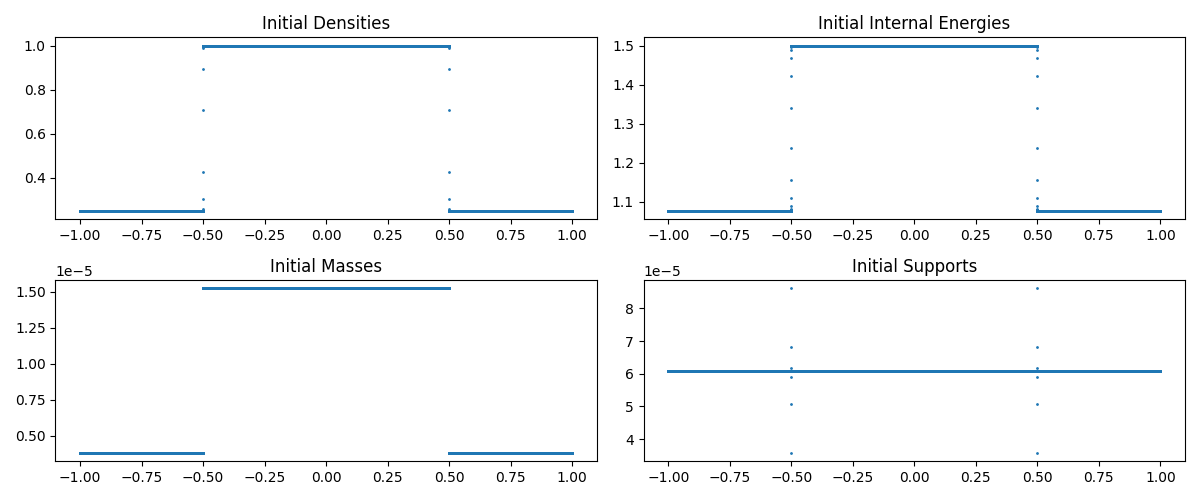

In [5]:
fig, axis = plt.subplots(2,2, figsize = (12, 5), squeeze = False)
plotToAxis1D(axis[0,0], compSystem.state.positions, compSystem.state.densities, title = 'Initial Densities')
plotToAxis1D(axis[1,0], compSystem.state.positions, compSystem.state.masses, title = 'Initial Masses')
plotToAxis1D(axis[0,1], compSystem.state.positions, compSystem.state.internalEnergies, title = 'Initial Internal Energies')
plotToAxis1D(axis[1,1], compSystem.state.positions, compSystem.state.supports, title = 'Initial Supports')
fig.tight_layout()

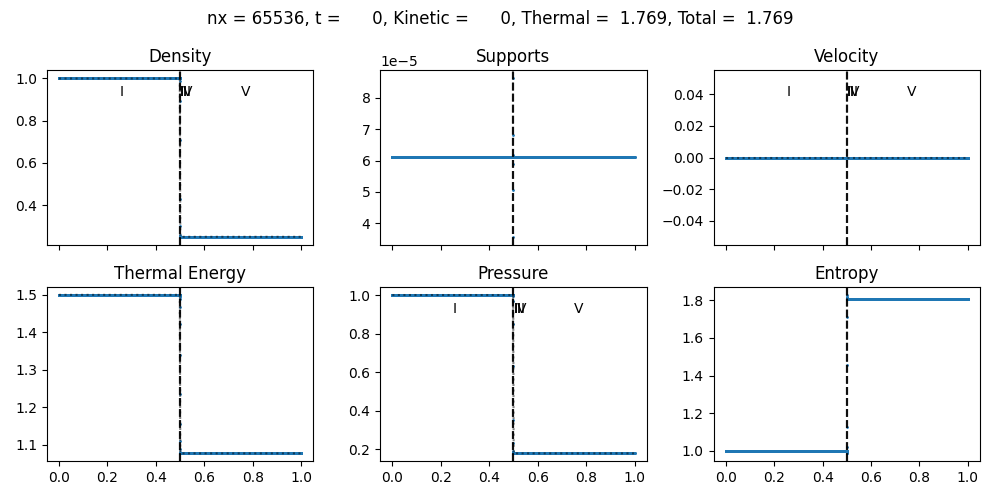

In [6]:
plotSod(compSystem.state, None, None, gamma, leftState, rightState, plotReference = True, plotLabels = True, scatter = True, t_ = compSystem.t)

In [7]:
update, adjacency, state = compressibleSPH_Monaghan(compSystem, config.dt, config, compressibleSPHConfig, verbose = True)

Module sphWarpCore.operations.wp_gradient f0134b6 load on device 'cuda:0' took 2.62 ms  (cached)
Module sphWarpCore.operations.wp_divergence 5883463 load on device 'cuda:0' took 2.35 ms  (cached)
Module compressibleSPH.modules.dissipation.wp_diffusion cef1a46 load on device 'cuda:0' took 3.47 ms  (cached)
Module compressibleSPH.modules.dissipation.wp_conductivity 06f9e7d load on device 'cuda:0' took 3.53 ms  (cached)
Module compressibleSPH.modules.dissipation.wp_dissipation ebe53d7 load on device 'cuda:0' took 2.65 ms  (cached)


In [8]:


with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], record_shapes=True) as prof:

    stepResult = integrator.function(
        state = compSystem,
        f = compressibleSPH_Monaghan,
        dt = config.dt,
        config = config,
        compParams = compressibleSPHConfig,
        verbose = False,
    )

print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=10))
prof.export_chrome_trace("warp_trace.json")

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                  [Integration] Butcher         0.89%     367.255us        99.84%      41.277ms      41.277ms       0.000us         0.00%      10.903ms      10.903ms             1  
                              [Integration] Update Step         2.63%       1.089ms        54.57%      22.562ms       5.641ms       0.000us         0.00%      10.173ms       2.543ms             4  
         

In [9]:
MAX_NUM_OF_MEM_EVENTS_PER_SNAPSHOT = 100000
torch.cuda.memory._record_memory_history(
    max_entries=MAX_NUM_OF_MEM_EVENTS_PER_SNAPSHOT
)
import copy

runningState = compSystem.initializeNewState()
torch.cuda.empty_cache()
# print('step,allocatedMB,reservedMB')
for i in (tq := tqdm(range(16), leave = True)):
    stageResults = integrator.function(
        state = runningState,
        f = compressibleSPH_Monaghan,
        dt = config.dt,
        config = config,
        compParams = compressibleSPHConfig,
        verbose = False,
    )
    # torch.cuda.empty_cache()

    runningState = stageResults.state
    # runningState = copy.deepcopy(stageResults.state)
    # runningState.adjacency = None
    # del stageResults

    # a = torch.cuda.memory_allocated()/1024/1024
    # r = torch.cuda.memory_reserved()/1024/1024
    # print(f'{i},{a:.2f},{r:.2f}')
torch.cuda.memory._dump_snapshot(f"memviz.pickle")

  0%|          | 0/16 [00:00<?, ?it/s]

In [ ]:
t_limit = 0.25
nSteps = int(t_limit / config.dt)

print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
nSteps = 1024

runningState = compSystem.initializeNewState()
for i in (tq := tqdm(range(nSteps), leave = True)):
    result = integrator.function(
        state = runningState,
        f = compressibleSPH_Monaghan,
        dt = config.dt,
        config = config,
        compParams = compressibleSPHConfig,
        verbose = False,
    )

    runningState = result.state

Running with dt: 1.4181087401337568e-05, which gives nSteps: 17629


  0%|          | 0/1024 [00:00<?, ?it/s]

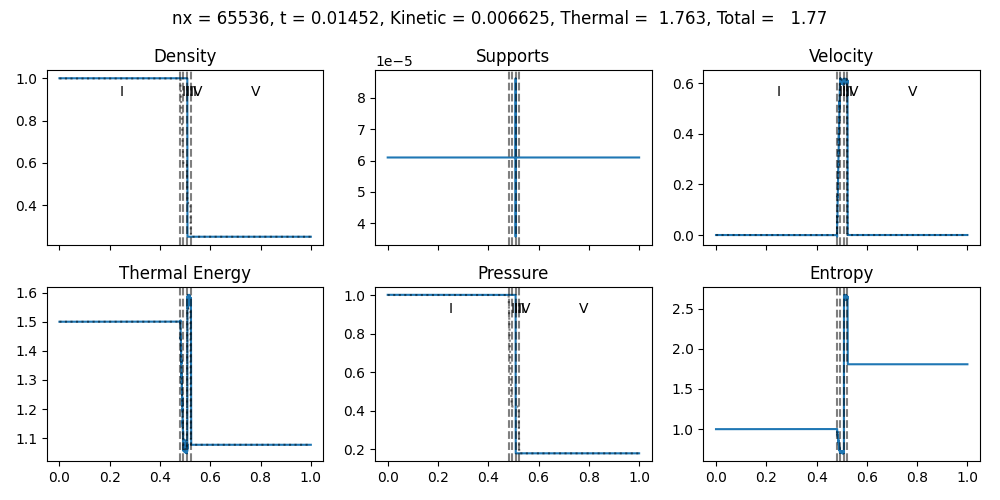

In [18]:
plotSod(runningState.state, None, None, gamma, leftState, rightState, plotReference = True, plotLabels = True, scatter = False, t_ = runningState.t)

In [1]:
config.dt

NameError: name 'config' is not defined